### Setup Imports and Plotting Configurations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

## 1. Gaussian / Normal Distribution (`np.random.normal`)
### Overview & Purpose
- The fundamental distribution in statistics and machine learning, governed by the Central Limit Theorem. 
- Used for modeling measurement errors, feature standardization, weight initialization in neural networks, and residual analysis.

### Mathematical Formula
The Probability Density Function (PDF) $f(x)$ for a Normal distribution $\mathcal{N}(\mu, \sigma^2)$ is:

$$f(x; \mu, \sigma) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left( -\frac{1}{2} \left( \frac{x - \mu}{\sigma} \right)^2 \right)$$

**Pronunciation & Symbol Guide:**
* $\mu$: Population mean / expected value (*mu*, pronounced *mew*).
* $\sigma$: Standard deviation (*sigma*).
* $\sigma^2$: Variance (*sigma squared*).
* $\pi$: Mathematical constant pi ($\approx 3.14159$).

### Parameters
* `loc`: `float` — Mean $\mu$ (center of the bell curve).
* `scale`: `float` — Standard deviation $\sigma$ (spread/width of the distribution).
* `size`: `int` or `tuple` — Output array dimensions.

Target Parameters: mu = 1.0, sigma = 1.5
Empirical Mean: 0.9819487353261238
Empirical Standard Deviation: 1.4469608814607138
Sample Range : min = -4.883600377427514, max = 5.152560408438915


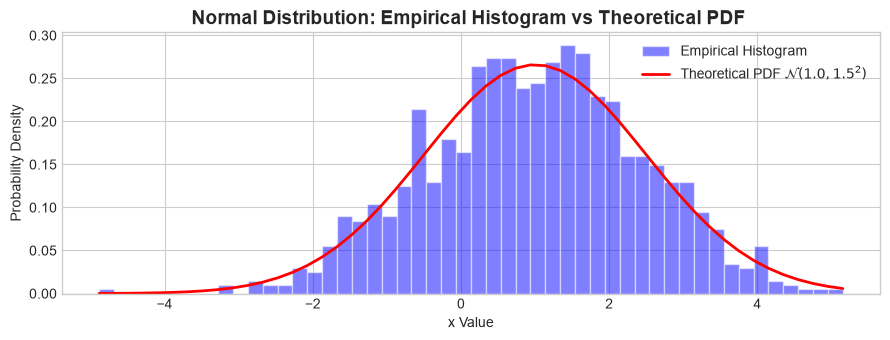

In [ ]:
mu, sigma = 0.0, 1.5

# parameters for the normal distribution
# loc : mu : mean of the distribution
# scale : sigma : standard deviation of the distribution
# size : number of samples to generate
sample_normal = np.random.normal(mu, sigma, 1000)

empirical_mean = np.mean(sample_normal)
empirical_std = np.std(sample_normal)

# print all values
print(f"Target Parameters: mu = {mu}, sigma = {sigma}")
print(f"Empirical Mean: {empirical_mean}")
print(f"Empirical Standard Deviation: {empirical_std}")
print(f"Sample Range : min = {np.min(sample_normal)}, max = {np.max(sample_normal)}")

# graphical visualization
# parameters for the histogram
# bins : number of bins
# density : normalize the histogram
# alpha : transparency
# color : color of the bars
# edgecolor : color of the edges
# label : label for the legend

plt.figure(figsize=(9, 3.5))
count, bins, ignored = plt.hist(sample_normal, bins=50, density=True, alpha=0.5, color="blue",edgecolor="white", label="Empirical Histogram")

# parameters for the PDF of the normal distribution
# loc : mu : mean of the distribution
# scale : sigma : standard deviation of the distribution
pdf_normal = stats.norm.pdf(bins, loc=mu, scale=sigma)

# parameters for the plot
# bins : x-axis values for the PDF
# pdf_normal : y-axis values for the PDF
# 'r-' : red solid line
# linewidth : width of the line
# label : label for the legend
plt.plot(bins, pdf_normal, 'r-', linewidth=2, label=f"Theoretical PDF $\\mathcal{{N}}({mu}, {sigma}^2)$")
plt.title("Normal Distribution: Empirical Histogram vs Theoretical PDF ",
          fontsize=14,fontweight='bold')
plt.xlabel("x Value")
plt.ylabel("Probability Density")
plt.legend(loc="upper right")
plt.tight_layout() # adjust subplots to fit into figure area.
plt.show()






### Real-World Applications of Gaussian / Normal Distribution (`np.random.normal`)

* **Machine Learning Weight Initialization:** Neural networks initialize weights using Gaussian distributions to ensure smooth signal flow across layers without exploding or vanishing gradients.
* **Adding Noise for Robustness:** Developers inject slight random variations into audio, image, or sensor data to train AI models to handle real-world static and distortion.
* **Financial Risk & Market Simulations:** Quantitative analysts use Monte Carlo simulations driven by normal distributions to model daily stock price fluctuations and assess portfolio risk.
* **A/B Testing & Medical Analysis:** Statistical tests rely on the assumption that human metrics (e.g., blood pressure, response times, session durations) follow a bell curve to confirm significant results.
* **Mock Data Generation:** Programmers generate realistic synthetic datasets—such as user heights, test scores, or delivery times—to prototype dashboards and applications before real data is available.
* **Manufacturing Quality Control:** Factories monitor product specifications (e.g., bottle fill levels, part dimensions). Measurements naturally form a bell curve, helping identify defect rates outside tolerance bounds.

---
---

## 2. Continuous Uniform Distribution (`np.random.uniform`)
### Overview & Purpose
- Models events where every outcome within a bounded interval $[a, b]$ is equally likely. 
- Essential for baseline hyperparameter search, random initialization bounds (Xavier/He uniform), and Inverse Transform Sampling algorithms.

### Mathematical Formula
The Probability Density Function (PDF) $f(x)$ for $\mathcal{U}(a, b)$ is:

$$f(x; a, b) = \begin{cases} \frac{1}{b - a}, & \text{for } a \le x \le b \\ 0, & \text{otherwise} \end{cases}$$

**Pronunciation & Symbol Guide:**
* $a$: Lower bound interval limit (*a*).
* $b$: Upper bound interval limit (*b*).
* $\frac{1}{b-a}$: Constant height of the uniform probability density box.

### Parameters
* `low`: `float` — Lower boundary $a$ (inclusive).
* `high`: `float` — Upper boundary $b$ (exclusive or inclusive depending on floating point rounding).
* `size`: `int` or `tuple` — Output shape.

Interval Bounds : [-2.00, 5.00]
Theoretical Mean : 1.5 | Empirical Mean : 1.5445030213621198
Theoretical Variance : 4.083333333333333 | Empirical Variance : 4.313141207700759


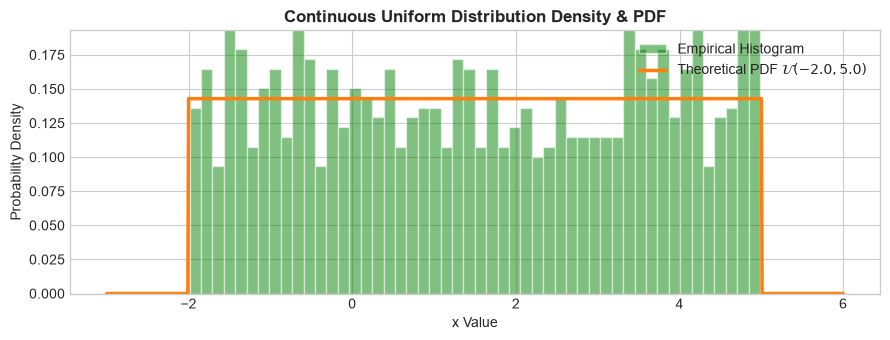

In [ ]:
a, b = -2.0, 5.0
# np.random.uniform parameters used
# low : a : lower bound of the distribution
# high : b : upper bound of the distribution
# size : number of samples to generate
samples_uniform = np.random.uniform(a, b, 1000)
theoretical_mean = (a + b) / 2.0
theoretical_var = ((b - a) ** 2) / 12.0

print(f"Interval Bounds : [{a:.2f}, {b:.2f}]")
print(f"Theoretical Mean : {theoretical_mean} | Empirical Mean : {np.mean(samples_uniform)}")
print(f"Theoretical Variance : {theoretical_var} | Empirical Variance : {np.var(samples_uniform)}")

plt.figure(figsize=(9, 3.5))
# density=True normalizes the histogram so that the area under the histogram equals 1
plt.hist(samples_uniform, bins=50, density=True, alpha=0.5, color="green", edgecolor="white", label="Empirical Histogram")

x_axis = np.linspace(a-1.0, b+1.0, 1000)
pdf_uniform = stats.uniform.pdf(x_axis, loc=a, scale=b-a)

plt.plot(x_axis, pdf_uniform, color='#ff7f0e', linewidth=2.5, label=f'Theoretical PDF $\\mathcal{{U}}({a}, {b})$')
plt.title('Continuous Uniform Distribution Density & PDF', fontsize=12, fontweight='bold')
plt.xlabel('x Value')
plt.ylabel('Probability Density')
plt.ylim(0, 1.0 / (b - a) + 0.05)                    # Set vertical axis slightly above box height
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 3. Exponential Distribution (`np.random.exponential`)

### Overview & Purpose
Models the continuous time interval between independent Poisson point events (e.g., time between customer arrivals, server request delays, component failure lifespans). Possesses the key **memoryless property**.

### Mathematical Formula
Given rate parameter $\lambda > 0$ or scale parameter $\beta = \frac{1}{\lambda}$ (mean duration):

$$f(x; \lambda) = \begin{cases} \lambda e^{-\lambda x}, & \text{for } x \ge 0 \\ 0, & \text{for } x < 0 \end{cases}$$

**Pronunciation & Symbol Guide:**
* $\lambda$: Event rate parameter (*lambda*).
* $\beta = \frac{1}{\lambda}$: Scale parameter / mean waiting time (*beta* or *scale*).
* $e$: Euler's constant ($\approx 2.71828$).

### Parameters
* `scale`: `float` — The scale parameter $\beta = \frac{1}{\lambda}$ (mean value of the distribution).
* `size`: `int` or `tuple` — Output shape.

=== 3. EXPONENTIAL DISTRIBUTION OUTPUT ===
Target Scale (beta = 1/lambda) : 2.00
Empirical Mean                : 2.0371
Empirical Variance            : 4.1671 (Theoretical: 4.00)
Median Waiting Time           : 1.4100



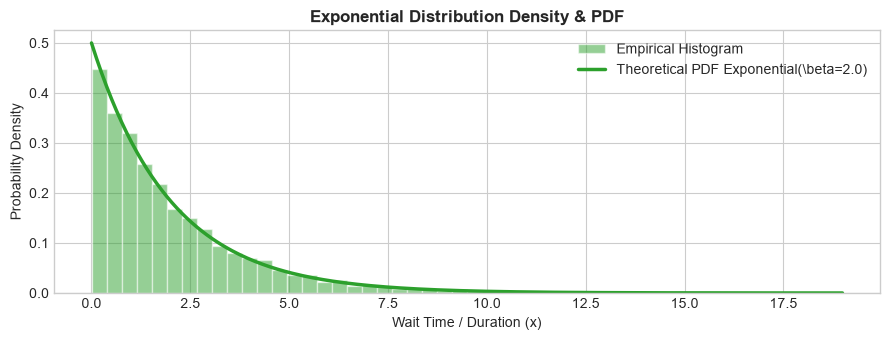

In [17]:
# --- 1. DATA GENERATION & PRINT OUTPUT ---
beta_scale = 2.0                                    # Mean duration scale beta = 2.0 (Rate lambda = 0.5)

# np.random.exponential Function Parameters Explained:
# - scale=beta_scale: Scale parameter beta = 1/lambda representing average duration between arrivals (2.0)
# - size=10000       : Number of random waiting times sampled
samples_exp = np.random.exponential(scale=beta_scale, size=10000)

print("=== 3. EXPONENTIAL DISTRIBUTION OUTPUT ===")
print(f"Target Scale (beta = 1/lambda) : {beta_scale:.2f}")
print(f"Empirical Mean                : {np.mean(samples_exp):.4f}")
print(f"Empirical Variance            : {np.var(samples_exp):.4f} (Theoretical: {beta_scale**2:.2f})")
print(f"Median Waiting Time           : {np.median(samples_exp):.4f}\n")

# --- 2. GRAPHICAL VISUALIZATION ---
plt.figure(figsize=(9, 3.5))

# Histogram parameters detailed:
# - density=True: Heights scaled to yield unit total area
# - bins=50: Discrete intervals along exponential tail
# - alpha=0.5: Translucency level
# - color='#2ca02c': Forest green
# - edgecolor='white': Sharp boundary outlines
plt.hist(samples_exp, bins=50, density=True, alpha=0.5, color='#2ca02c', edgecolor='white', label='Empirical Histogram')

x_exp = np.linspace(0, np.max(samples_exp), 300)

# stats.expon.pdf Parameters Explained:
# - x (x_exp)         : Array of positive continuous evaluation values starting at 0
# - scale=beta_scale  : Scale parameter beta = 1/lambda matching mean duration (2.0)
pdf_exp = stats.expon.pdf(x_exp, scale=beta_scale)

# Plot formatting parameters detailed:
# - color='#2ca02c': Forest green line curve
# - linewidth=2.5: Line width
plt.plot(x_exp, pdf_exp, color='#2ca02c', linewidth=2.5, label=rf'Theoretical PDF Exponential(\beta={beta_scale})')

plt.title('Exponential Distribution Density & PDF', fontsize=12, fontweight='bold')
plt.xlabel('Wait Time / Duration (x)')
plt.ylabel('Probability Density')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

=== COFFEE SHOP DOOR BELL: TIME BETWEEN DINGS ===
Target Average Interval (Minutes) : 2.00
Observed Mean Wait Time          : 1.9550
Observed Variance               : 3.7975 (Theoretical: 4.00)
Median Wait Time Between Dings  : 1.3566



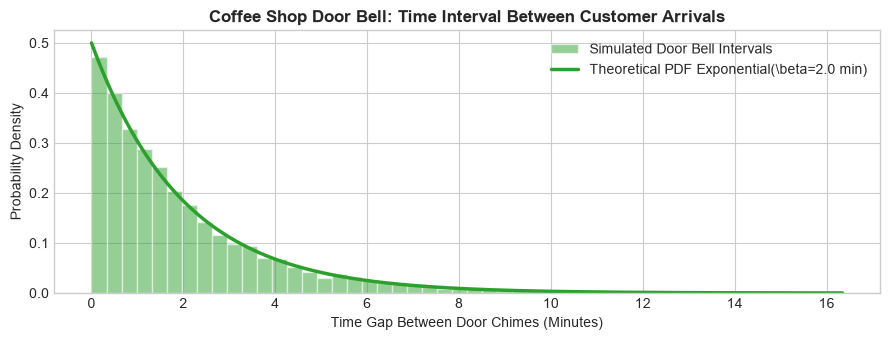

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

avg_wait_minutes = 2.0  # On average, a door bell "Ding!" happens every 2 minutes (lambda = 0.5 dings/min)
num_ding_intervals = 10000

ding_intervals = np.random.exponential(scale=avg_wait_minutes, size=num_ding_intervals)

print("=== COFFEE SHOP DOOR BELL: TIME BETWEEN DINGS ===")
print(f"Target Average Interval (Minutes) : {avg_wait_minutes:.2f}")
print(f"Observed Mean Wait Time          : {np.mean(ding_intervals):.4f}")
print(f"Observed Variance               : {np.var(ding_intervals):.4f} (Theoretical: {avg_wait_minutes**2:.2f})")
print(f"Median Wait Time Between Dings  : {np.median(ding_intervals):.4f}\n")

plt.figure(figsize=(9, 3.5))

plt.hist(ding_intervals, bins=50, density=True, alpha=0.5, color='#2ca02c', edgecolor='white', label='Simulated Door Bell Intervals')

x_intervals = np.linspace(0, np.max(ding_intervals), 300)
pdf_intervals = stats.expon.pdf(x_intervals, scale=avg_wait_minutes)

plt.plot(x_intervals, pdf_intervals, color='#2ca02c', linewidth=2.5, label=rf'Theoretical PDF Exponential(\beta={avg_wait_minutes} min)')

plt.title('Coffee Shop Door Bell: Time Interval Between Customer Arrivals', fontsize=12, fontweight='bold')
plt.xlabel('Time Gap Between Door Chimes (Minutes)')
plt.ylabel('Probability Density')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()